# BoundaryAttack on scikit-learn models — Scaled to [0,1] (Option A)

Notebook scales features to [0,1], trains models, runs untargeted BoundaryAttack, saves adversarial examples (including adversarial feature vectors), and creates quick visualizations.

Edit DATA_PATH at the top to point to your CSV if needed. The notebook expects a label column named `anomaly` or the last column will be treated as the label.

In [1]:
# Install if necessary (uncomment)
# !pip install adversarial-robustness-toolbox scikit-learn xgboost pandas numpy matplotlib


In [2]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

try:
    from xgboost import XGBClassifier
    has_xgb = True
except Exception:
    XGBClassifier = None
    has_xgb = False

from art.attacks.evasion import BoundaryAttack
from art.estimators.classification import SklearnClassifier

print('xgboost available:', has_xgb)

xgboost available: True


In [ ]:
# === Configuration: change DATA_PATH string if needed ===
DATA_PATH = 'C:/Users/Jan/Git/AnomalyDetection/CSVs/newDataset.csv'  
LABEL_COL = 'anomaly'                    # or set to your label column name
TEST_SIZE = 0.8
RANDOM_STATE = 100

# Scaling to [0,1] (Option A)
CLIP_VALUES = (0.0, 1.0)

# Recommended BoundaryAttack params for scaled data (Option A)
N_ATTACK = 2122  # number of samples to attack
BOUNDARY_PARAMS = dict(
    max_iter = 200,
    delta    = 0.01,
    epsilon  = 1e-6,
    targeted = False
)

OUT_DIR = Path('Results/BoundaryAttack_optionA')
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
# --- Load data ---
DATA_PATH_OBJ = Path(DATA_PATH)
assert DATA_PATH_OBJ.exists(), f"CSV not found: {DATA_PATH}"
df = pd.read_csv(DATA_PATH_OBJ)

if LABEL_COL not in df.columns:
    print(f"Warning: label column '{LABEL_COL}' not found. Using last column as label instead.")
    LABEL_COL = df.columns[-1]

y = df[LABEL_COL].astype(int).values
feature_cols = [c for c in df.columns if c != LABEL_COL]
X = df[feature_cols].values

print('Loaded:', DATA_PATH_OBJ, 'samples=', X.shape[0], 'features=', X.shape[1])


Loaded: C:\Users\Jan\Git\AnomalyDetection\CSVs\newDataset.csv samples= 2123 features= 22


In [5]:
# --- Train/Test split & scaling to [0,1] ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE,
                                                    stratify=y, random_state=RANDOM_STATE)

scaler = MinMaxScaler(feature_range=CLIP_VALUES)
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print('Shapes:', X_train_sc.shape, X_test_sc.shape)

Shapes: (424, 22) (1699, 22)


In [6]:
# --- Train sklearn models (simple defaults) ---
models = {}
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
lr.fit(X_train_sc, y_train); models['LogisticRegression'] = lr

mlp = MLPClassifier(hidden_layer_sizes=(128,64), max_iter=300, random_state=RANDOM_STATE)
mlp.fit(X_train_sc, y_train); models['MLPClassifier'] = mlp

svm = SVC(probability=True, kernel='rbf', random_state=RANDOM_STATE)
svm.fit(X_train_sc, y_train); models['SVM'] = svm

rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
rf.fit(X_train_sc, y_train); models['RandomForest'] = rf

if has_xgb:
    xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=RANDOM_STATE)
    xgb.fit(X_train_sc, y_train); models['XGBClassifier'] = xgb
else:
    print('XGBoost not available; skipped.')

for name, m in models.items():
    print(f"{name}: test acc =", accuracy_score(y_test, m.predict(X_test_sc)))

LogisticRegression: test acc = 0.8987639788110653
MLPClassifier: test acc = 0.9446733372572101
SVM: test acc = 0.8917010005885815
RandomForest: test acc = 0.9440847557386698
XGBClassifier: test acc = 0.9440847557386698


In [7]:
# --- Wrap with ART SklearnClassifier ---
art_classifiers = {}
for name, m in models.items():
    try:
        clf = SklearnClassifier(model=m, clip_values=CLIP_VALUES)
        art_classifiers[name] = clf
    except Exception as e:
        print(f"Could not wrap {name}: {e}")


Could not wrap XGBClassifier: Model is not an sklearn model. Received '<class 'xgboost.sklearn.XGBClassifier'>'


In [8]:
# Helper: convert ART/sklearn predict outputs to 1D labels
def art_probs_to_labels(probs):
    probs = np.asarray(probs)
    if probs.ndim == 1:
        return (probs >= 0.5).astype(int)
    if probs.ndim == 2:
        if probs.shape[1] == 1:
            return (probs.ravel() >= 0.5).astype(int)
        return np.argmax(probs, axis=1).astype(int)
    raise ValueError(f"Unexpected prediction shape: {probs.shape}")

In [9]:
# --- Run untargeted BoundaryAttack on a subset and save adversarial examples ---
from sklearn.metrics import accuracy_score
n_attack = min(N_ATTACK, X_test_sc.shape[0])
X_eval = X_test_sc[:n_attack]
y_eval = y_test[:n_attack].astype(int)

results = {}
for name, clf in art_classifiers.items():
    print('\n' + '='*60)
    print('Attacking model:', name)
    try:
        attack = BoundaryAttack(estimator=clf, **BOUNDARY_PARAMS)
        # untargeted: don't pass y (passing y may be interpreted as targets)
        X_adv = attack.generate(x=X_eval)
        # Convert predictions to labels
        y_pred_clean = art_probs_to_labels(clf.predict(X_eval))
        y_pred_adv   = art_probs_to_labels(clf.predict(X_adv))

        acc_clean = accuracy_score(y_eval, y_pred_clean)
        acc_adv   = accuracy_score(y_eval, y_pred_adv)
        print(f"Clean acc: {acc_clean:.4f} | Adv acc: {acc_adv:.4f}")
        results[name] = dict(clean_acc=acc_clean, adv_acc=acc_adv)

        # Save adversarial examples with both clean and adv features (inverse scaled to original)
        X_clean_inv = scaler.inverse_transform(X_eval)
        X_adv_inv   = scaler.inverse_transform(X_adv)

        df_out = pd.DataFrame(X_clean_inv, columns=feature_cols)
        # prefix adv features with adv_
        adv_cols = [f"adv_{c}" for c in feature_cols]
        df_adv = pd.DataFrame(X_adv_inv, columns=adv_cols)
        df_save = pd.concat([df_out.reset_index(drop=True), df_adv.reset_index(drop=True)], axis=1)
        df_save['label_true'] = y_eval
        df_save['pred_clean'] = y_pred_clean
        df_save['pred_adv'] = y_pred_adv

        save_path = OUT_DIR / f"{name}_adv_examples.csv"
        df_save.to_csv(save_path, index=False)
        print('Saved adversarial examples to:', save_path)
    except Exception as e:
        print('Attack failed for', name, ':', e)


Attacking model: LogisticRegression


Boundary attack:   9%|▊         | 146/1699 [00:22<03:56,  6.57it/s]


KeyboardInterrupt: 

## Quick visualizations
The next cell will load the saved CSVs and produce a summary table plus a bar chart of clean vs adversarial accuracy.

,model,clean_acc,adv_acc,flip_rate
0,RandomForest,0.944085,0.204826,0.826368
1,SVC,0.921719,0.200118,0.831077
2,MLPClassifier,0.944673,0.190700,0.811654
3,LogisticRegression,0.898764,0.104179,0.989994


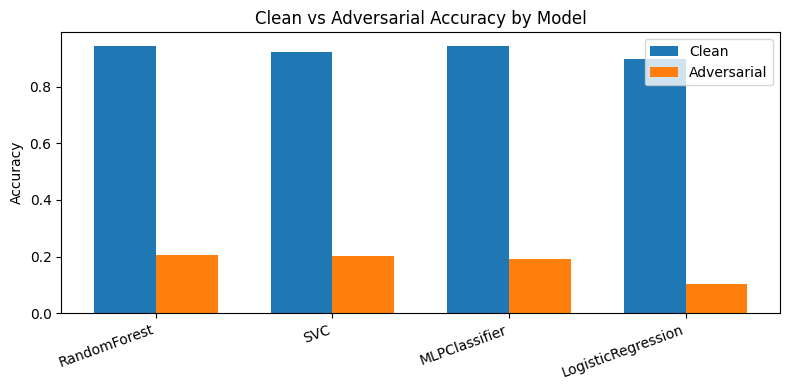

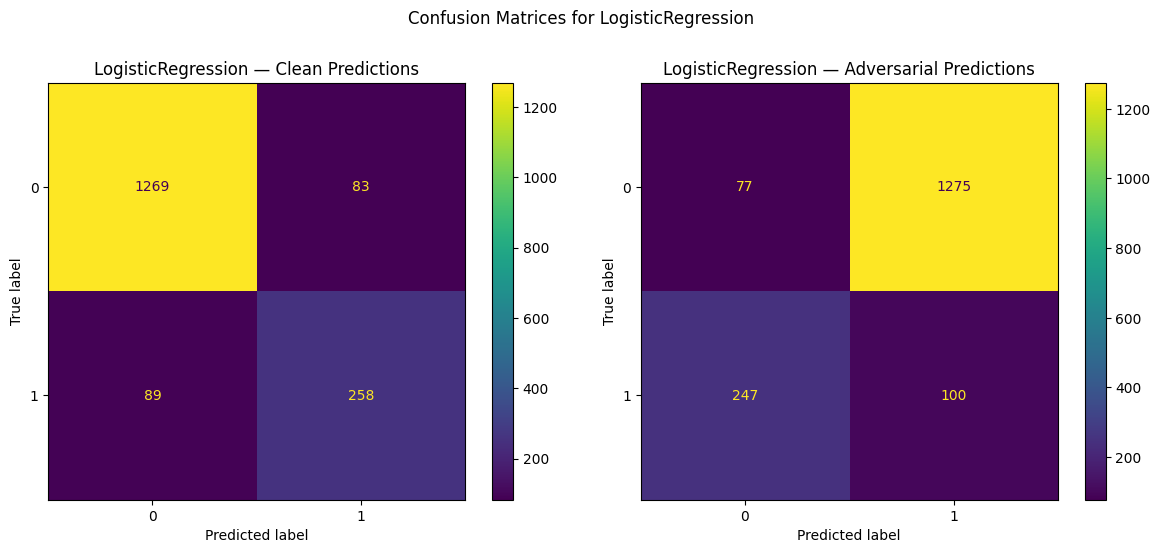

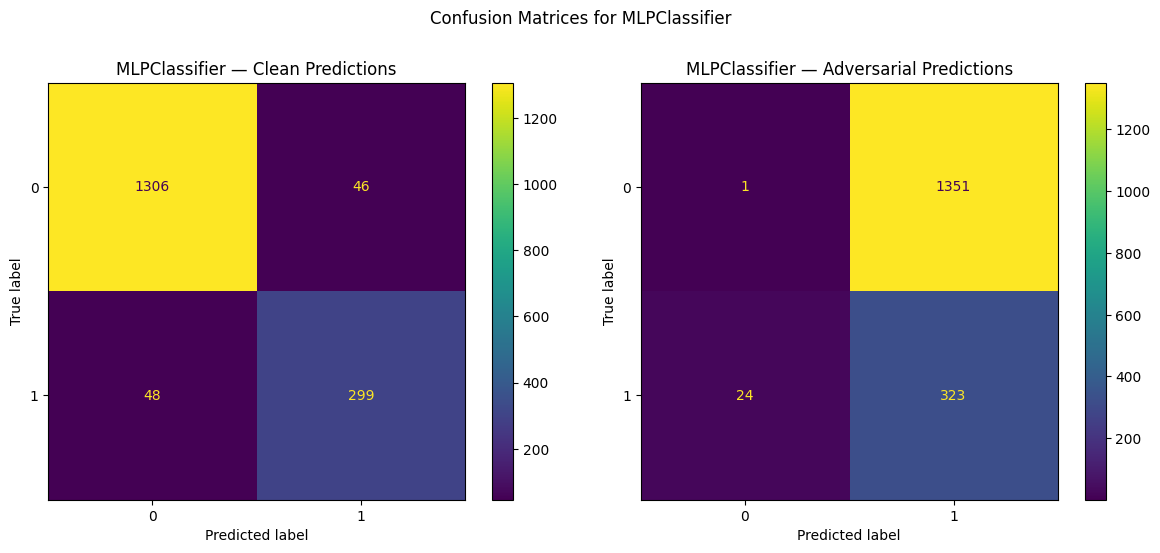

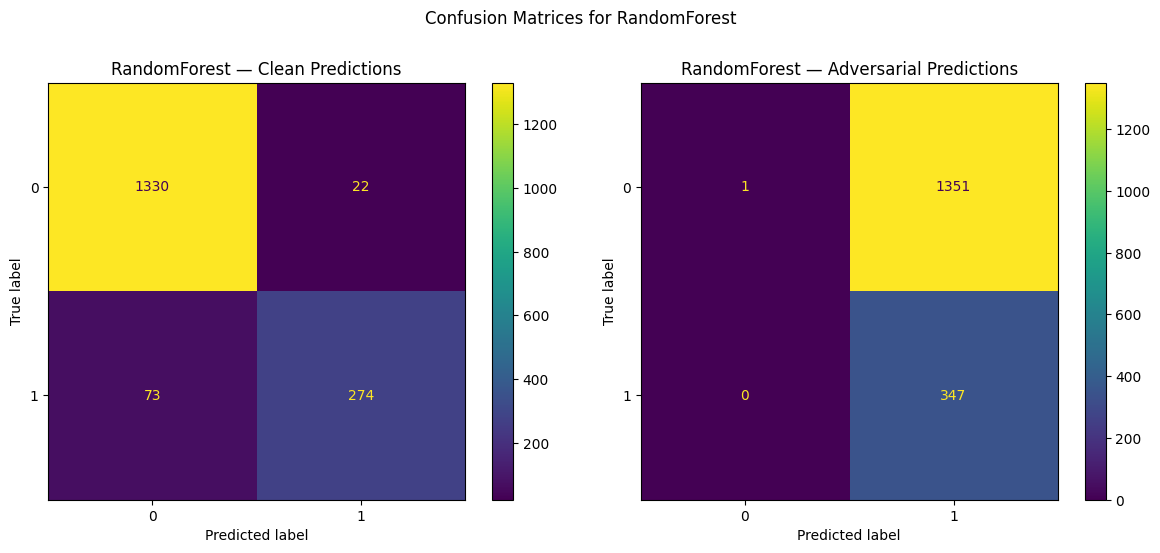

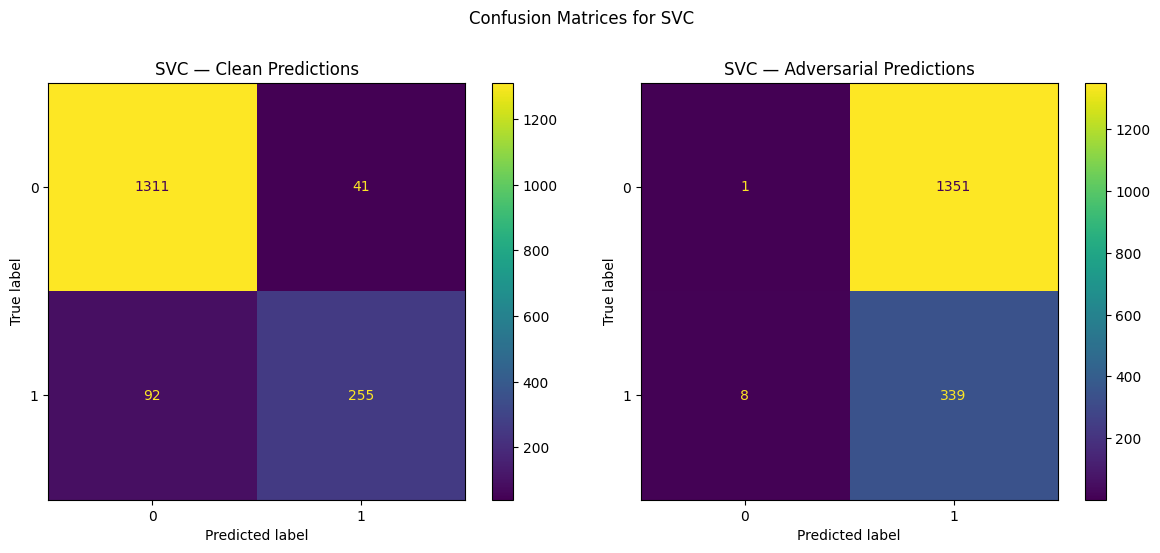

In [ ]:
# --- Visualize results from saved CSVs ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import accuracy_score

OUT_DIR = Path('Results/BoundaryAttack_optionA')  # <-- correct folder for Option A
files = list(OUT_DIR.glob('*_adv_examples_optionA.csv'))
if not files:
    raise FileNotFoundError(f'No CSVs found in {OUT_DIR}. '
                            f'Expected files like <Model>_adv_examples_optionA.csv')

summaries = []
per_model_frames = {}
for csv in files:
    name = csv.stem.replace('_adv_examples_optionA','')
    df = pd.read_csv(csv)
    per_model_frames[name] = df
    acc_clean = accuracy_score(df['label_true'], df['pred_clean'])
    acc_adv   = accuracy_score(df['label_true'], df['pred_adv'])
    flip_rate = (df['pred_clean'] != df['pred_adv']).mean()
    summaries.append({'model': name, 'clean_acc': acc_clean, 'adv_acc': acc_adv, 'flip_rate': flip_rate})

summary_df = pd.DataFrame(summaries)
if summary_df.empty:
    raise RuntimeError('Summary DataFrame is empty — no results aggregated.')
summary_df = summary_df.sort_values('adv_acc', ascending=False).reset_index(drop=True)
display(summary_df)

# Bar chart
labels = summary_df['model'].tolist()
clean  = summary_df['clean_acc'].values
adv    = summary_df['adv_acc'].values

plt.figure(figsize=(8,4))
x = np.arange(len(labels))
w = 0.35
plt.bar(x - w/2, clean, width=w, label='Clean')
plt.bar(x + w/2, adv,   width=w, label='Adversarial')
plt.xticks(x, labels, rotation=20, ha='right')
plt.ylabel('Accuracy')
plt.title('Clean vs Adversarial Accuracy by Model')
plt.legend()
plt.tight_layout()
plt.show()

# Using sklearn's ConfusionMatrixDisplay with side-by-side comparisons
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

for name, df in per_model_frames.items():
    y_true = df['label_true'].to_numpy()
    
    # Create a figure with two subplots side by side
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Plot clean predictions
    cm_clean = confusion_matrix(y_true, df['pred_clean'])
    disp_clean = ConfusionMatrixDisplay(cm_clean)
    disp_clean.plot(ax=ax1)
    ax1.set_title(f'{name} — Clean Predictions')
    
    # Plot adversarial predictions
    cm_adv = confusion_matrix(y_true, df['pred_adv'])
    disp_adv = ConfusionMatrixDisplay(cm_adv)
    disp_adv.plot(ax=ax2)
    ax2.set_title(f'{name} — Adversarial Predictions')
    
    plt.suptitle(f'Confusion Matrices for {name}', y=1.05)
    plt.tight_layout()
    plt.show()